Trained model loaded perfectly and ready for evaluation!
tensor(0.4142)
Test Accuracy: 87.64%
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       114
           1       0.91      0.94      0.93       294
           2       0.00      0.00      0.00        13
           4       0.00      0.00      0.00        24

    accuracy                           0.88       445
   macro avg       0.43      0.48      0.45       445
weighted avg       0.81      0.88      0.84       445



C:\Users\npubu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\npubu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\npubu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

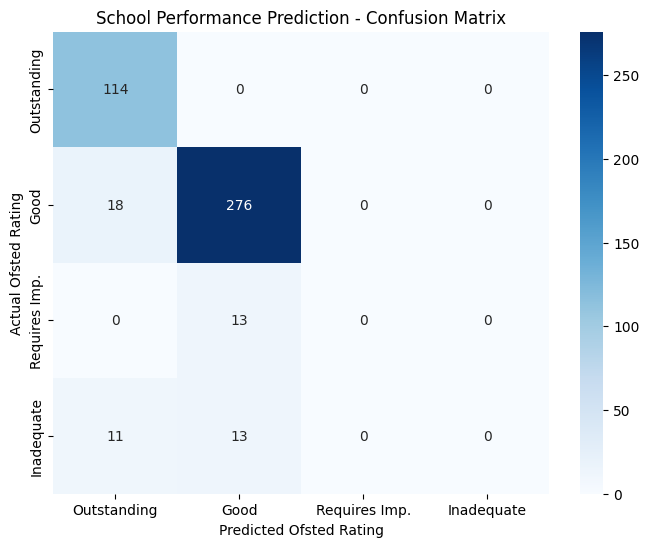

: 

In [ ]:
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

sys.path.append('../../')
from SRC.models.ann_model import MLP

# 1. Recreate the basic structure because it is still in ann_model.py
model = MLP()

# 2. Load the exact weights 
model.load_state_dict(torch.load('../../models/ofsted_ann_model.pt'))

# 3. Switch to evaluation mode
model.eval()
print("Trained model loaded perfectly and ready for evaluation!")

# 2. Load the exact test data
x_test = torch.FloatTensor(np.load('../../data/x_test.npy'))
y_test = torch.LongTensor(np.load('../../data/y_test.npy'))

criterion = torch.nn.CrossEntropyLoss()

# Pass the test data through the model without calculating gradients
with torch.no_grad():#turn off the back propagation
    test_outputs = model.forward(x_test)
    loss= criterion(test_outputs, y_test)

    print(loss)
    
    # Get the index of the highest logit (this is the predicted class 0, 1, 2, 3, or 4)
    _, predictions = torch.max(test_outputs, 1)
    
    # Calculate how many predictions matched the actual y_test labels
    correct = (predictions == y_test).sum().item()
    total = y_test.size(0)
    accuracy = (correct / total) * 100

print(f"Test Accuracy: {accuracy:.2f}%")

# 1. Convert PyTorch tensors back to NumPy arrays for Scikit-Learn
y_true = y_test.numpy()
y_pred = predictions.numpy()

# 2. Generate a detailed text report (Precision, Recall, F1-Score)
print("--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 3. Plot a beautiful Confusion Matrix heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Outstanding', 'Good', 'Requires Imp.', 'Inadequate'],
            yticklabels=['Outstanding', 'Good', 'Requires Imp.', 'Inadequate'])
plt.ylabel('Actual Ofsted Rating')
plt.xlabel('Predicted Ofsted Rating')
plt.title('School Performance Prediction - Confusion Matrix')
plt.show()